# Actividad 2

__Curso:__ Tópicos avanzados en Inteligencia Artificial 1

__Programa:__ MIA 2-2025

__Profesor:__ Anthony D. Cho

__Ayudante corrector:__ Luis Oliveros


## Instrucciones

* La actividad debe ser realizada por los grupos capstones.
* Por favor responder en este mismo notebook (una entrega por grupo).
* Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo `actividad2_Sakuragi_Mitsui_Rukagua_Sendoh.ipynb`.
* Subir el archivo al enlace de entrega Actividad 2 en Webcursos que será habilitado.

__Fecha de entrega:__ 06 de septiembre de 2026, 23:59 horas de Chile.


__Integrantes:__ (RUT, Nombre y Apellido)

* 13.257.556-8, Ricardo Lopez
* 16.789.149-7, Camilo Muñoz


In [1]:
!python -m pip install kagglehub

## Librerías


In [2]:
import gc
import os
import random
import time
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Activation,
    Add,
    BatchNormalization,
    Concatenate,
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    GlobalAveragePooling1D,
    Input,
    MaxPooling1D,
    SeparableConv1D,
    TextVectorization,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CHECKPOINT_DIR = Path("/content") if Path("/content").exists() else Path(".")

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {bool(tf.config.list_physical_devices('GPU'))}")
print("En Colab se recomienda: Entorno de ejecución > Cambiar tipo de entorno > T4 GPU.")


TensorFlow: 2.20.0
GPU disponible: True
En Colab se recomienda: Entorno de ejecución > Cambiar tipo de entorno > T4 GPU.


## Funciones personalizadas


In [3]:
def plot_history(history, width=12, height_per_metric=4):
    '''Grafica cada métrica de entrenamiento junto con su validación.'''
    metric_names = [
        key
        for key in history.history
        if not key.startswith("val_") and key != "learning_rate"
    ]
    epochs = np.arange(1, len(history.epoch) + 1)
    fig, axes = plt.subplots(
        len(metric_names),
        1,
        figsize=(width, height_per_metric * len(metric_names)),
        squeeze=False,
    )

    for axis, metric_name in zip(axes.ravel(), metric_names):
        axis.plot(epochs, history.history[metric_name], "o-", label=metric_name)
        validation_name = f"val_{metric_name}"
        if validation_name in history.history:
            axis.plot(
                epochs,
                history.history[validation_name],
                "o-",
                label=validation_name,
            )
        axis.set_xlabel("Epoch")
        axis.set_ylabel(metric_name)
        axis.grid(alpha=0.3)
        axis.legend()

    plt.tight_layout()
    plt.show()


def make_callbacks(checkpoint_path):
    '''Crea callbacks nuevos para evitar compartir estado entre modelos.'''
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
    ]


def training_summary(model, history, training_time):
    '''Resume costo y convergencia usando el mejor val_loss observado.'''
    best_epoch_index = int(np.argmin(history.history["val_loss"]))
    return {
        "params": int(model.count_params()),
        "epochs_run": int(len(history.epoch)),
        "best_epoch": best_epoch_index + 1,
        "best_val_loss": float(history.history["val_loss"][best_epoch_index]),
        "training_time": float(training_time),
    }


def evaluate_binary_model(model, X_test_numeric, y_test_numeric, model_name, threshold=0.5):
    '''Muestra matriz, reporte y devuelve métricas comparables de test.'''
    evaluation = model.evaluate(
        X_test_numeric,
        y_test_numeric,
        batch_size=BATCH_SIZE,
        verbose=0,
        return_dict=True,
    )
    probabilities = model.predict(
        X_test_numeric,
        batch_size=BATCH_SIZE,
        verbose=1,
    ).ravel()
    predictions = (probabilities >= threshold).astype(np.int32)

    matrix = confusion_matrix(y_test_numeric, predictions, labels=[0, 1])
    report = classification_report(
        y_test_numeric,
        predictions,
        labels=[0, 1],
        target_names=["Negativa", "Positiva"],
        output_dict=True,
        zero_division=0,
    )

    print(f"\n{model_name} - pérdida en test: {evaluation['loss']:.4f}")
    print(f"Umbral de decisión: {threshold:.2f}")
    print("\nMatriz de confusión:")
    print(matrix)

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Negativa", "Positiva"],
    )
    display_matrix.plot(cmap="Blues", values_format="d")
    plt.title(f"Matriz de confusión - {model_name}")
    plt.grid(False)
    plt.show()

    print("Reporte de clasificación:")
    print(
        classification_report(
            y_test_numeric,
            predictions,
            labels=[0, 1],
            target_names=["Negativa", "Positiva"],
            digits=4,
            zero_division=0,
        )
    )

    return {
        "test_loss": float(evaluation["loss"]),
        "test_accuracy": float(report["accuracy"]),
        "precision_neg": float(report["Negativa"]["precision"]),
        "recall_neg": float(report["Negativa"]["recall"]),
        "f1_neg": float(report["Negativa"]["f1-score"]),
        "precision_pos": float(report["Positiva"]["precision"]),
        "recall_pos": float(report["Positiva"]["recall"]),
        "f1_pos": float(report["Positiva"]["f1-score"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
    }


### Configuración de entrenamiento

Se fija `EPOCHS = 20` como máximo de entrenamiento, pero el número efectivo de épocas queda regulado por `EarlyStopping`. Para evitar una parada demasiado agresiva se usa `patience=6` y `min_delta=1e-4`, manteniendo `restore_best_weights=True` para conservar el mejor punto según `val_loss`.


## Dataset

<center>
    <img src="https://www.danielle-moss.com/wp-content/uploads/2021/04/Horizontal-Homepage-4.png" width="800">
</center>

El conjunto de datos contiene alrededor de 183 mil revisiones de productos de bebé con sus respectivas valoraciones, recopiladas desde Amazon.

* Los datos y sus detalles están disponibles en [Kaggle: Reviews of Amazon Baby Products](https://www.kaggle.com/datasets/sameersmahajan/reviews-of-amazon-baby-products).


#### Carga de datos


In [4]:
dataset_path = Path(
    kagglehub.dataset_download("sameersmahajan/reviews-of-amazon-baby-products")
)
csv_candidates = list(dataset_path.rglob("amazon_baby.csv"))
if not csv_candidates:
    csv_candidates = list(dataset_path.rglob("*.csv"))
if not csv_candidates:
    raise FileNotFoundError(f"No se encontró un CSV dentro de {dataset_path}")

csv_file = csv_candidates[0]
raw_data = pd.read_csv(csv_file)
raw_data.columns = raw_data.columns.str.strip().str.lower()

required_columns = {"review", "rating"}
missing_columns = required_columns.difference(raw_data.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

data = raw_data[["review", "rating"]].copy()
original_rows = len(data)
data["rating"] = pd.to_numeric(data["rating"], errors="coerce")
data["review"] = data["review"].fillna("").astype(str).str.strip()
data = data[data["rating"].isin([1, 2, 3, 4, 5]) & data["review"].ne("")].copy()
data["rating"] = data["rating"].astype(np.int8)

# Se conserva la lógica incluida en el notebook inicial.
data["sentiment"] = np.where(data["rating"].isin([1, 2, 3]), 0, 1).astype(np.int8)

print(f"Archivo: {csv_file}")
print(f"Filas originales: {original_rows:,}")
print(f"Filas válidas después de limpiar: {len(data):,}")
display(data.head(4))


100%|██████████| 29.4M/29.4M [00:01<00:00, 16.7MB/s]

Extracting files...


Archivo: /root/.cache/kagglehub/datasets/sameersmahajan/reviews-of-amazon-baby-products/versions/1/amazon_baby.csv
Filas originales: 183,531
Filas válidas después de limpiar: 182,702


,review,rating,sentiment
0,"These flannel wipes are OK, but in my opinion ...",3,0
1,it came early and was not disappointed. i love...,5,1
2,Very soft and comfortable and warmer than it l...,5,1
3,This is a product well worth the purchase. I ...,5,1


### Criterio de sentimiento

El comentario del notebook inicial indica que los ratings 1 y 2 son negativos, pero su código asigna la clase 0 a los ratings 1, 2 y 3. Para mantener la reproducibilidad con la lógica efectivamente proporcionada se usa:

* Clase 0, negativa: ratings 1, 2 y 3.
* Clase 1, positiva: ratings 4 y 5.

La misma definición se mantiene durante todo el notebook.


#### Partición de los datos


In [5]:
X = data["review"].to_numpy(dtype=str)
y = data["sentiment"].to_numpy(dtype=np.int32)

X_train, X_test, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=SEED,
    stratify=y,
)

print(f"Train - X: {X_train.shape}, y: {y_train_np.shape}")
print(f"Test  - X: {X_test.shape}, y: {y_test_np.shape}")
print("\nDistribución porcentual por partición:")
distribution = pd.DataFrame({"train": pd.Series(y_train_np).value_counts(normalize=True),
                             "test": pd.Series(y_test_np).value_counts(normalize=True)}).sort_index()
distribution.index = ["Negativa (0)", "Positiva (1)"]
display((distribution * 100).round(2).astype(str) + "%")


Train - X: (164431,), y: (164431,)
Test  - X: (18271,), y: (18271,)

Distribución porcentual por partición:


,train,test
Negativa (0),23.6%,23.6%
Positiva (1),76.4%,76.4%


## Actividades


#### Paso 1 (5 puntos):

Transforme los datos de reviews (train y test) a numéricos, preservando la cantidad de tokens suficientes para poder usar el modelo Xception visto en clase. Escale los datos transformados en caso de ser necesario.


### Exploración y decisiones de representación

La longitud se estima solo con `X_train`. Así, las decisiones de preprocesamiento no incorporan información del conjunto de prueba.


Estadísticas de longitud de reviews en train:


,Cantidad de palabras
count,164431.00
mean,82.00
std,86.76
min,1.00
50%,55.00
75%,100.00
90%,168.00
95%,230.00
99%,425.00
max,2714.00


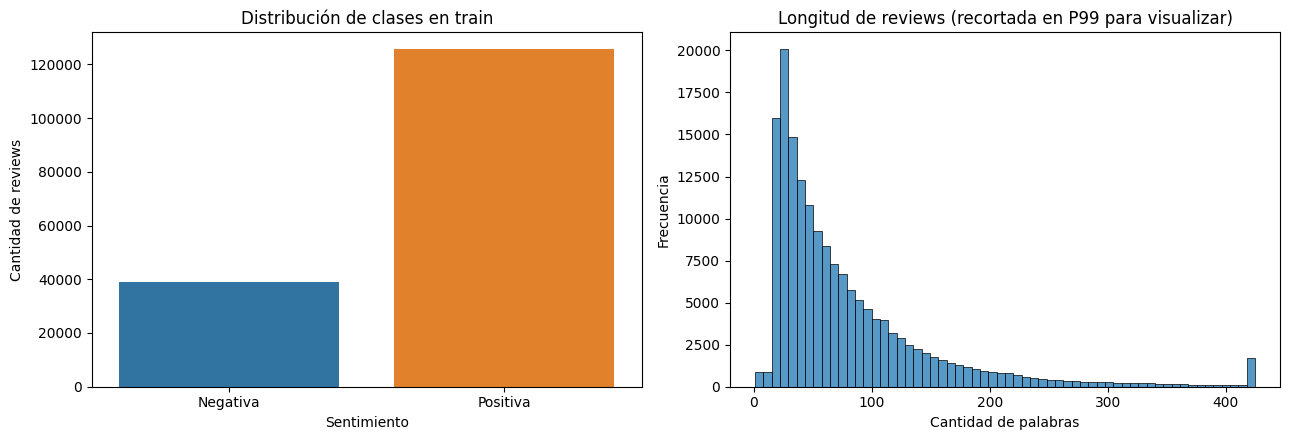

In [6]:
review_lengths = pd.Series([len(review.split()) for review in X_train], name="words")
length_summary = review_lengths.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

print("Estadísticas de longitud de reviews en train:")
display(length_summary.to_frame("Cantidad de palabras"))

class_counts = pd.Series(y_train_np).value_counts().sort_index()
class_counts.index = ["Negativa", "Positiva"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], hue=class_counts.index, legend=False)
axes[0].set_title("Distribución de clases en train")
axes[0].set_ylabel("Cantidad de reviews")
axes[0].set_xlabel("Sentimiento")

p99 = int(review_lengths.quantile(0.99))
sns.histplot(review_lengths.clip(upper=p99), bins=60, ax=axes[1])
axes[1].set_title("Longitud de reviews (recortada en P99 para visualizar)")
axes[1].set_xlabel("Cantidad de palabras")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### Tokenización

Se usa un vocabulario máximo de 20.000 tokens, suficiente para conservar términos frecuentes sin aumentar de forma excesiva el tamaño del `Embedding`. La longitud de secuencia se fija en 256 tokens: las reviews más largas se truncan y las más cortas reciben padding con ceros. La cobertura exacta de esta decisión se calcula abajo con los datos de entrenamiento.

`TextVectorization` se adapta exclusivamente con `X_train`, evitando fuga de información desde test. Su estandarización por defecto convierte a minúsculas y elimina puntuación.


In [7]:
MAX_TOKENS = 20_000
SEQUENCE_LENGTH = 256
VECTORIZATION_BATCH_SIZE = 2_048

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    name="text_vectorization",
)
vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(X_train).batch(VECTORIZATION_BATCH_SIZE)
)

vocabulary = vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocabulary)


def vectorize_in_batches(texts):
    '''Vectoriza sin crear un tensor intermedio gigante en memoria.'''
    encoded = np.empty((len(texts), SEQUENCE_LENGTH), dtype=np.int32)
    for start in range(0, len(texts), VECTORIZATION_BATCH_SIZE):
        stop = min(start + VECTORIZATION_BATCH_SIZE, len(texts))
        encoded[start:stop] = vectorizer(
            tf.convert_to_tensor(texts[start:stop])
        ).numpy()
    return encoded


X_train_tokenized = vectorize_in_batches(X_train)
X_test_tokenized = vectorize_in_batches(X_test)

coverage = float((review_lengths <= SEQUENCE_LENGTH).mean())
print(f"Vocabulario aprendido: {VOCAB_SIZE:,} tokens")
print(f"Longitud de secuencia: {SEQUENCE_LENGTH}")
print(f"Reviews de train con hasta {SEQUENCE_LENGTH} palabras: {coverage:.2%}")


Vocabulario aprendido: 20,000 tokens
Longitud de secuencia: 256
Reviews de train con hasta 256 palabras: 96.12%


### Evaluación del escalamiento

No se aplica `StandardScaler`. Cada entero es el identificador categórico de un token, no una cantidad cuya magnitud tenga significado. Estandarizar esos índices produciría números continuos incompatibles con la capa `Embedding` y destruiría la correspondencia entre índice y palabra. La representación densa y aprendible se obtiene dentro del modelo mediante `Embedding`.


In [8]:
assert X_train_tokenized.shape == (len(X_train), SEQUENCE_LENGTH)
assert X_test_tokenized.shape == (len(X_test), SEQUENCE_LENGTH)
assert X_train_tokenized.dtype == np.int32
assert X_test_tokenized.dtype == np.int32
assert X_train_tokenized.min() >= 0
assert X_train_tokenized.max() < VOCAB_SIZE

example_index = 0
example_tokens = X_train_tokenized[example_index]
non_padding_ids = example_tokens[example_tokens != 0][:20]
decoded_tokens = [vocabulary[token_id] for token_id in non_padding_ids]

print(f"X_train numérico: {X_train_tokenized.shape}, dtype={X_train_tokenized.dtype}")
print(f"X_test numérico:  {X_test_tokenized.shape}, dtype={X_test_tokenized.dtype}")
print(f"y_train: {y_train_np.shape}, y_test: {y_test_np.shape}")
print("\nReview original:")
print(X_train[example_index][:500])
print("\nPrimeros 20 índices distintos de padding:")
print(non_padding_ids)
print("\nTokens correspondientes:")
print(decoded_tokens)


X_train numérico: (164431, 256), dtype=int32
X_test numérico:  (18271, 256), dtype=int32
y_train: (164431,), y_test: (18271,)

Review original:
Like many moms, I was looking for a toy to occupy my Son while I was bathing him...I found this toy in my local Walmart when my son was about 7mos. and it was a great pick. My sons enjoying picking and playing with the fish while I bathe him. He likes playing with the Net also, however he have not grasp the fact that it the Net is made to scoop the fish; I slso combine other small toys that could fit in the Net also. Now that my son is 10mos this toy has not grown old to him, it grabs his attent

Primeros 20 índices distintos de padding:
[  41  205  911    5   17  219   10    7  174    6 6353   12   75  125
    5   17 2383 8213  222    9]

Tokens correspondientes:
[np.str_('like'), np.str_('many'), np.str_('moms'), np.str_('i'), np.str_('was'), np.str_('looking'), np.str_('for'), np.str_('a'), np.str_('toy'), np.str_('to'), np.str_('occupy'), n

#### Paso 2 (5 puntos):

Entrene el modelo Xception —visto en clase— con los datos procesados en el Paso 1. Entregue la matriz de confusión y el reporte de clasificación con el conjunto de prueba.


### Arquitectura Xception 1D base

Para trabajar con texto se emplean convoluciones 1D. El modelo conserva los principios de Xception: conexiones residuales, convoluciones separables en profundidad, `Entry Flow`, `Middle Flow` y `Exit Flow`. Las dos primeras capas del `Entry Flow` son convoluciones tradicionales; en el Paso 3 se reemplazará únicamente la segunda.


In [9]:
EMBEDDING_DIM = 128
DROPOUT_RATE = 0.25
MIDDLE_BLOCKS = 4
BATCH_SIZE = 128
EPOCHS = 20
VALIDATION_SIZE = 0.15


def add_downsampling_block(x, filters, block_name, dropout_rate):
    residual = Conv1D(
        filters, 1, strides=2, padding="same", use_bias=False,
        name=f"{block_name}_residual_conv",
    )(x)
    residual = BatchNormalization(name=f"{block_name}_residual_bn")(residual)

    x = SeparableConv1D(
        filters, 8, padding="same", use_bias=False,
        name=f"{block_name}_sepconv_1",
    )(x)
    x = BatchNormalization(name=f"{block_name}_bn_1")(x)
    x = Activation("relu", name=f"{block_name}_relu_1")(x)
    x = SeparableConv1D(
        filters, 8, padding="same", use_bias=False,
        name=f"{block_name}_sepconv_2",
    )(x)
    x = BatchNormalization(name=f"{block_name}_bn_2")(x)
    x = MaxPooling1D(3, strides=2, padding="same", name=f"{block_name}_pool")(x)
    x = Add(name=f"{block_name}_add")([x, residual])
    x = Activation("relu", name=f"{block_name}_relu_2")(x)
    return Dropout(dropout_rate, name=f"{block_name}_dropout")(x)


def add_xception_body(x, dropout_rate, middle_blocks):
    '''Cuerpo compartido por ambos modelos después de la segunda capa del Entry Flow.'''
    x = add_downsampling_block(x, 128, "entry_block_1", dropout_rate)
    x = add_downsampling_block(x, 256, "entry_block_2", dropout_rate)

    for block_index in range(1, middle_blocks + 1):
        residual = x
        block_name = f"middle_block_{block_index}"
        for conv_index in range(1, 4):
            x = SeparableConv1D(
                256, 8, padding="same", use_bias=False,
                name=f"{block_name}_sepconv_{conv_index}",
            )(x)
            x = BatchNormalization(name=f"{block_name}_bn_{conv_index}")(x)
            if conv_index < 3:
                x = Activation("relu", name=f"{block_name}_relu_{conv_index}")(x)
        x = Add(name=f"{block_name}_add")([x, residual])
        x = Activation("relu", name=f"{block_name}_relu_3")(x)
        x = Dropout(dropout_rate, name=f"{block_name}_dropout")(x)

    residual = Conv1D(
        512, 1, strides=2, padding="same", use_bias=False,
        name="exit_residual_conv",
    )(x)
    residual = BatchNormalization(name="exit_residual_bn")(residual)

    x = SeparableConv1D(512, 8, padding="same", use_bias=False, name="exit_sepconv_1")(x)
    x = BatchNormalization(name="exit_bn_1")(x)
    x = Activation("relu", name="exit_relu_1")(x)
    x = SeparableConv1D(512, 8, padding="same", use_bias=False, name="exit_sepconv_2")(x)
    x = BatchNormalization(name="exit_bn_2")(x)
    x = MaxPooling1D(3, strides=2, padding="same", name="exit_pool")(x)
    x = Add(name="exit_add")([x, residual])
    x = Activation("relu", name="exit_relu_2")(x)
    x = Dropout(dropout_rate, name="exit_dropout")(x)

    x = SeparableConv1D(768, 8, padding="same", use_bias=False, name="exit_sepconv_3")(x)
    x = BatchNormalization(name="exit_bn_3")(x)
    x = Activation("relu", name="exit_relu_3")(x)
    x = GlobalAveragePooling1D(name="global_average_pooling")(x)
    return Dense(1, activation="sigmoid", name="sentiment")(x)


def build_xception_text(vocab_size, sequence_length, embedding_dim, dropout_rate):
    inputs = Input(shape=(sequence_length,), dtype="int32", name="tokens")
    x = Embedding(vocab_size, embedding_dim, mask_zero=False, name="embedding")(inputs)
    x = Conv1D(32, 8, padding="same", use_bias=False, name="entry_conv_1")(x)
    x = BatchNormalization(name="entry_conv_1_bn")(x)
    x = Activation("relu", name="entry_conv_1_relu")(x)

    # Segunda convolución tradicional del Entry Flow.
    x = Conv1D(64, 8, padding="same", use_bias=False, name="entry_conv_2")(x)
    x = BatchNormalization(name="entry_conv_2_bn")(x)
    x = Activation("relu", name="entry_conv_2_relu")(x)

    outputs = add_xception_body(x, dropout_rate, MIDDLE_BLOCKS)
    return Model(inputs, outputs, name="Xception_1D_Base")


### Partición de validación y balance de clases


In [10]:
train_indices, validation_indices = train_test_split(
    np.arange(len(y_train_np)),
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_train_np,
)

X_model_train = X_train_tokenized[train_indices]
y_model_train = y_train_np[train_indices]
X_validation = X_train_tokenized[validation_indices]
y_validation = y_train_np[validation_indices]

# La matriz original deja de ser necesaria; liberar memoria ayuda en Colab.
del X_train_tokenized
gc.collect()

classes = np.unique(y_model_train)
balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_model_train,
)
CLASS_WEIGHTS = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, balanced_weights)
}

print(f"Entrenamiento del modelo: {X_model_train.shape}")
print(f"Validación: {X_validation.shape}")
print(f"Test reservado: {X_test_tokenized.shape}")
print(f"Pesos de clase: {CLASS_WEIGHTS}")


Entrenamiento del modelo: (139766, 256)
Validación: (24665, 256)
Test reservado: (18271, 256)
Pesos de clase: {0: 2.118501227756389, 1: 0.6544638927129867}


### Entrenamiento del modelo Xception base


Model: "Xception_1D_Base"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  2,560,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_1        │ (None, 256, 32)   │     32,768 │ embedding[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_1_bn     │ (None, 256, 32)   │        128 │ entry_conv_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_1_relu   │ (None, 256, 32)   │          0 │ entry_conv_1_bn[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_2        │ (None, 256, 64)   │     16,384 │ entry_conv_1_rel… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_2_bn     │ (None, 256, 64)   │        256 │ entry_conv_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_2_relu   │ (None, 256, 64)   │          0 │ entry_conv_2_bn[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_sepc… │ (None, 256, 128)  │      8,704 │ entry_conv_2_rel… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_bn_1  │ (None, 256, 128)  │        512 │ entry_block_1_se… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_relu… │ (None, 256, 128)  │          0 │ entry_block_1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_sepc… │ (None, 256, 128)  │     17,408 │ entry_block_1_re… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_bn_2  │ (None, 256, 128)  │        512 │ entry_block_1_se… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_resi… │ (None, 128, 128)  │      8,192 │ entry_conv_2_rel… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_pool  │ (None, 128, 128)  │          0 │ entry_block_1_bn… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_resi… │ (None, 128, 128)  │        512 │ entry_block_1_re… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_add   │ (None, 128, 128)  │          0 │ entry_block_1_po… │
│ (Add)               │                   │            │ entry_block_1_re

 Total params: 4,543,617 (17.33 MB)

 Trainable params: 4,530,369 (17.28 MB)

 Non-trainable params: 13,248 (51.75 KB)

Epoch 1/20
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7841 - loss: 0.4386
Epoch 1: val_loss improved from None to 0.29518, saving model to /content/xception_base_best.weights.h5

Epoch 1: finished saving model to /content/xception_base_best.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 166s 107ms/step - accuracy: 0.8420 - loss: 0.3481 - val_accuracy: 0.8742 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 2/20
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9011 - loss: 0.2368
Epoch 2: val_loss did not improve from 0.29518
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 62s 57ms/step - accuracy: 0.9106 - loss: 0.2178 - val_accuracy: 0.7875 - val_loss: 0.5201 - learning_rate: 0.0010
Epoch 3/20
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9362 - loss: 0.1591
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.29518
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 62s 57ms/step - accuracy: 0.9454 - loss: 0.1397 - val_accurac

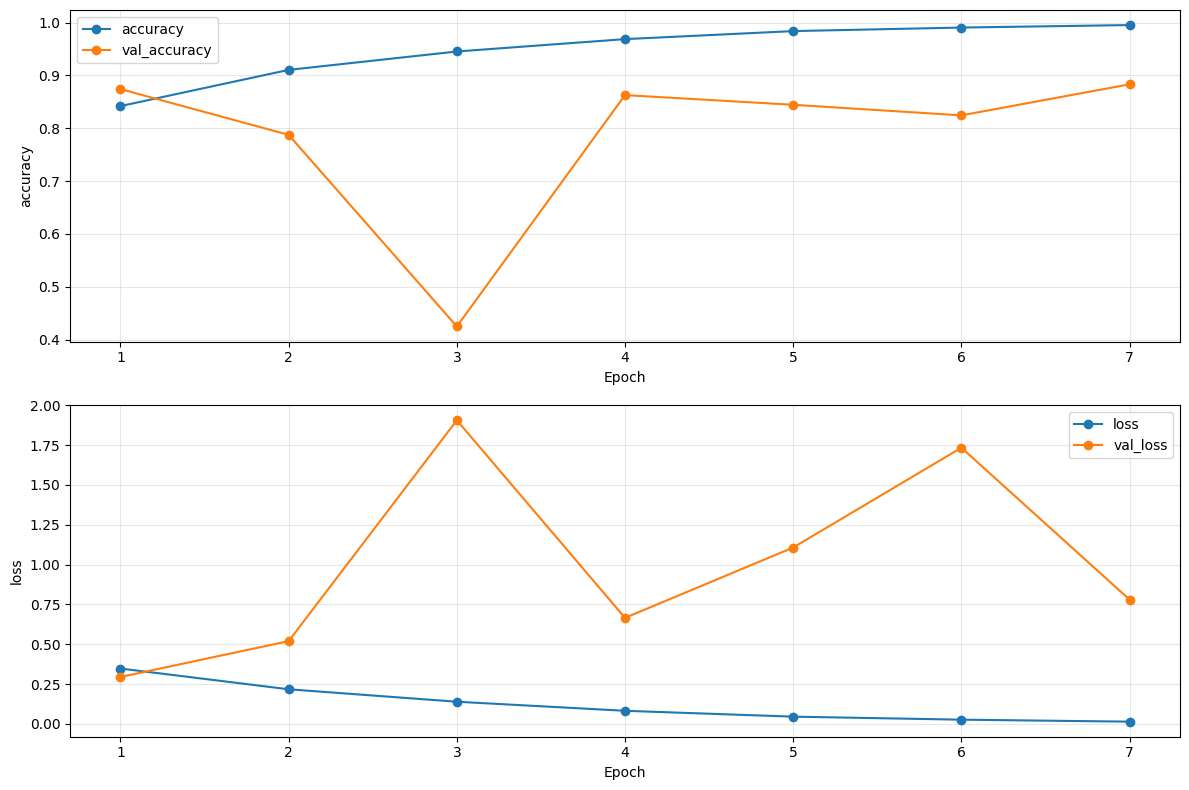

In [11]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

xception_base_model = build_xception_text(
    VOCAB_SIZE,
    SEQUENCE_LENGTH,
    EMBEDDING_DIM,
    DROPOUT_RATE,
)
xception_base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")],
)
xception_base_model.summary()

base_checkpoint = CHECKPOINT_DIR / "xception_base_best.weights.h5"
start_time = time.perf_counter()
history_xception_base = xception_base_model.fit(
    X_model_train,
    y_model_train,
    validation_data=(X_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks(base_checkpoint),
    shuffle=True,
    verbose=1,
)
training_time_base = time.perf_counter() - start_time
xception_base_model.load_weights(base_checkpoint)

print(f"Tiempo de entrenamiento: {training_time_base:.2f} segundos")
plot_history(history_xception_base)


### Evaluación del modelo Xception base en test


143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step

Xception base - pérdida en test: 0.2994
Umbral de decisión: 0.50

Matriz de confusión:
[[ 3928   384]
 [ 1972 11987]]


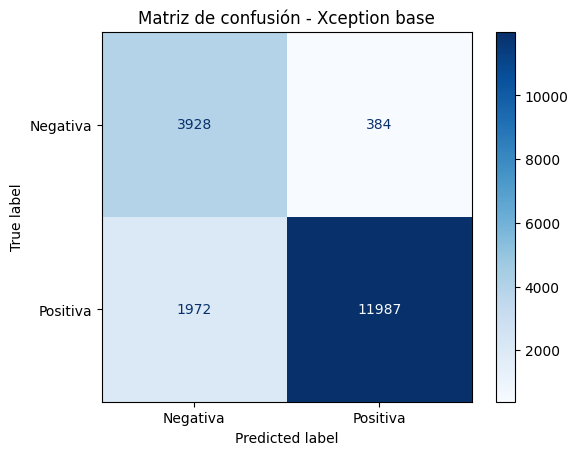

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativa     0.6658    0.9109    0.7693      4312
    Positiva     0.9690    0.8587    0.9105     13959

    accuracy                         0.8711     18271
   macro avg     0.8174    0.8848    0.8399     18271
weighted avg     0.8974    0.8711    0.8772     18271



In [12]:
xception_base_metrics = evaluate_binary_model(
    xception_base_model,
    X_test_tokenized,
    y_test_np,
    "Xception base",
)
xception_base_metrics.update(
    training_summary(
        xception_base_model,
        history_xception_base,
        training_time_base,
    )
)

# Guardar solo resultados y liberar el grafo antes de construir el segundo modelo.
del xception_base_model
gc.collect()
tf.keras.backend.clear_session()


#### Paso 3 (5 puntos):

Entrene un modelo Xception modificado, reemplazando solo la segunda capa convolucional tradicional del módulo de `Entry Flow` por un bloque Inception. Entregue la matriz de confusión y el reporte de clasificación con el conjunto de prueba.


### Modificación: bloque Inception 1D

El bloque recibe exactamente la salida de la primera convolución y produce 64 canales, igual que la segunda `Conv1D` del modelo base. Sus cuatro ramas usan kernels 1, 3 y 5, más `MaxPooling1D` seguido de una convolución 1. Cada rama aporta 16 canales y sus salidas se concatenan. Después se reutilizan la misma normalización, activación y todo el cuerpo Xception definido en el Paso 2; por ello la única modificación arquitectónica está en este punto del `Entry Flow`.


In [13]:
def inception_block_1d(x, filters_per_branch=16, block_name="entry_inception"):
    branch_1 = Conv1D(
        filters_per_branch, 1, padding="same", use_bias=False,
        name=f"{block_name}_conv_1",
    )(x)
    branch_3 = Conv1D(
        filters_per_branch, 3, padding="same", use_bias=False,
        name=f"{block_name}_conv_3",
    )(x)
    branch_5 = Conv1D(
        filters_per_branch, 5, padding="same", use_bias=False,
        name=f"{block_name}_conv_5",
    )(x)
    branch_pool = MaxPooling1D(
        3, strides=1, padding="same", name=f"{block_name}_pool"
    )(x)
    branch_pool = Conv1D(
        filters_per_branch, 1, padding="same", use_bias=False,
        name=f"{block_name}_pool_conv_1",
    )(branch_pool)
    return Concatenate(name=f"{block_name}_concat")(
        [branch_1, branch_3, branch_5, branch_pool]
    )


def build_xception_inception_text(vocab_size, sequence_length, embedding_dim, dropout_rate):
    inputs = Input(shape=(sequence_length,), dtype="int32", name="tokens")
    x = Embedding(vocab_size, embedding_dim, mask_zero=False, name="embedding")(inputs)
    x = Conv1D(32, 8, padding="same", use_bias=False, name="entry_conv_1")(x)
    x = BatchNormalization(name="entry_conv_1_bn")(x)
    x = Activation("relu", name="entry_conv_1_relu")(x)

    # Único reemplazo: entry_conv_2 del modelo base por el bloque Inception.
    x = inception_block_1d(x, filters_per_branch=16)
    if x.shape[-1] != 64:
        raise ValueError("El bloque Inception debe producir 64 canales.")
    x = BatchNormalization(name="entry_conv_2_bn")(x)
    x = Activation("relu", name="entry_conv_2_relu")(x)

    outputs = add_xception_body(x, dropout_rate, MIDDLE_BLOCKS)
    return Model(inputs, outputs, name="Xception_1D_Inception")


### Entrenamiento del modelo Xception + Inception


Model: "Xception_1D_Inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  2,560,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_1        │ (None, 256, 32)   │     32,768 │ embedding[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_1_bn     │ (None, 256, 32)   │        128 │ entry_conv_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_1_relu   │ (None, 256, 32)   │          0 │ entry_conv_1_bn[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_inception_po… │ (None, 256, 32)   │          0 │ entry_conv_1_rel… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_inception_co… │ (None, 256, 16)   │        512 │ entry_conv_1_rel… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_inception_co… │ (None, 256, 16)   │      1,536 │ entry_conv_1_rel… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_inception_co… │ (None, 256, 16)   │      2,560 │ entry_conv_1_rel… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_inception_po… │ (None, 256, 16)   │        512 │ entry_inception_… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_inception_co… │ (None, 256, 64)   │          0 │ entry_inception_… │
│ (Concatenate)       │                   │            │ entry_inception_… │
│                     │                   │            │ entry_inception_… │
│                     │                   │            │ entry_inception_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_2_bn     │ (None, 256, 64)   │        256 │ entry_inception_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv_2_relu   │ (None, 256, 64)   │          0 │ entry_conv_2_bn[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_sepc… │ (None, 256, 128)  │      8,704 │ entry_conv_2_rel… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_bn_1  │ (None, 256, 128)  │        512 │ entry_block_1_se… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_block_1_relu… │ (None, 256, 128)  │          0 │ entry_block_1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,532,353 (17.29 MB)

 Trainable params: 4,519,105 (17.24 MB)

 Non-trainable params: 13,248 (51.75 KB)

Epoch 1/20
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7844 - loss: 0.4397
Epoch 1: val_loss improved from None to 0.30925, saving model to /content/xception_inception_best.weights.h5

Epoch 1: finished saving model to /content/xception_inception_best.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 131s 90ms/step - accuracy: 0.8433 - loss: 0.3473 - val_accuracy: 0.8742 - val_loss: 0.3092 - learning_rate: 0.0010
Epoch 2/20
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9023 - loss: 0.2331
Epoch 2: val_loss did not improve from 0.30925
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 63s 57ms/step - accuracy: 0.9125 - loss: 0.2140 - val_accuracy: 0.8304 - val_loss: 0.4013 - learning_rate: 0.0010
Epoch 3/20
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9412 - loss: 0.1484
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.30925
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 63s 57ms/step - accuracy: 0.9494 - loss: 0.1315 - va

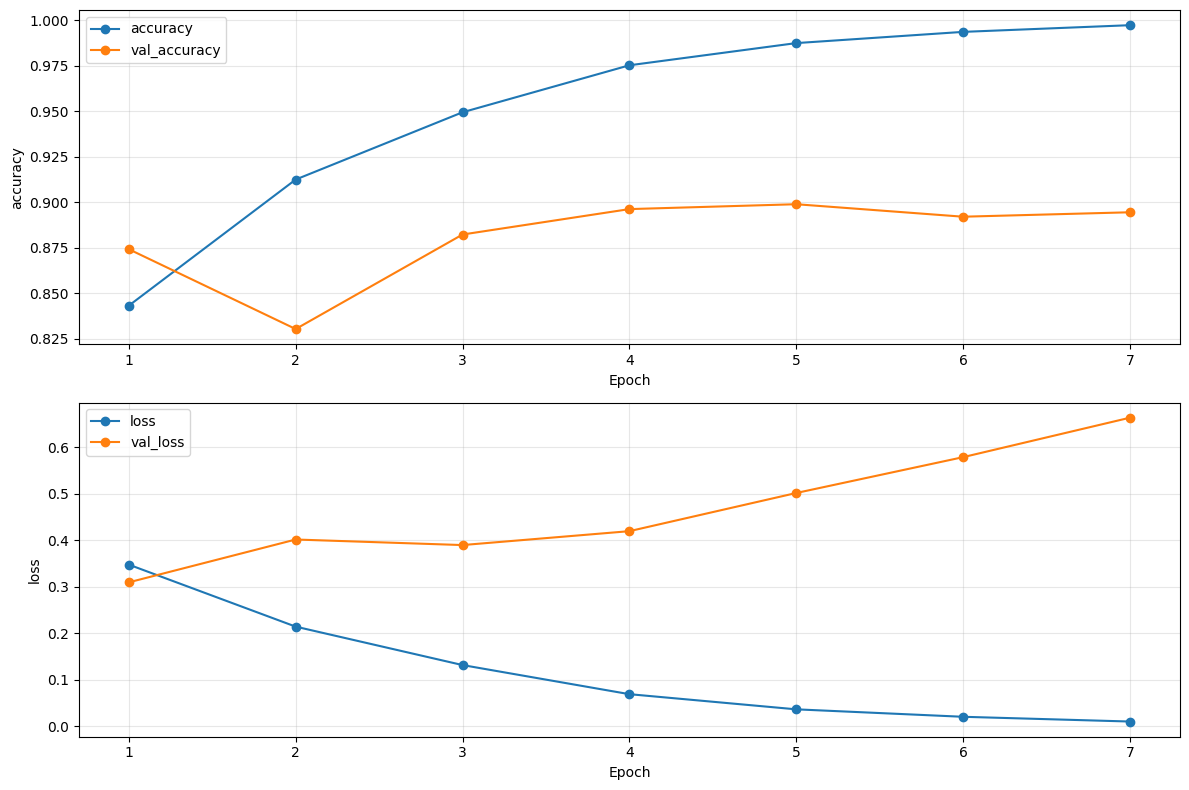

In [14]:
tf.keras.utils.set_random_seed(SEED)

xception_inception_model = build_xception_inception_text(
    VOCAB_SIZE,
    SEQUENCE_LENGTH,
    EMBEDDING_DIM,
    DROPOUT_RATE,
)
xception_inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")],
)
xception_inception_model.summary()

inception_checkpoint = CHECKPOINT_DIR / "xception_inception_best.weights.h5"
start_time = time.perf_counter()
history_xception_inception = xception_inception_model.fit(
    X_model_train,
    y_model_train,
    validation_data=(X_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks(inception_checkpoint),
    shuffle=True,
    verbose=1,
)
training_time_inception = time.perf_counter() - start_time
xception_inception_model.load_weights(inception_checkpoint)

print(f"Tiempo de entrenamiento: {training_time_inception:.2f} segundos")
plot_history(history_xception_inception)


### Evaluación del modelo Xception + Inception en test


143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step

Xception + Inception - pérdida en test: 0.3174
Umbral de decisión: 0.50

Matriz de confusión:
[[ 3988   324]
 [ 2049 11910]]


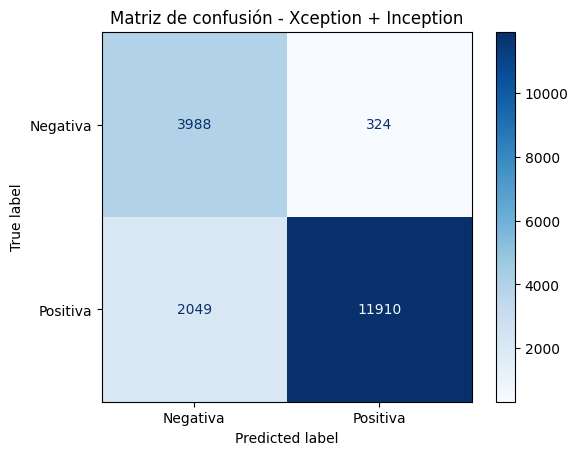

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativa     0.6606    0.9249    0.7707      4312
    Positiva     0.9735    0.8532    0.9094     13959

    accuracy                         0.8701     18271
   macro avg     0.8171    0.8890    0.8401     18271
weighted avg     0.8997    0.8701    0.8767     18271



In [15]:
xception_inception_metrics = evaluate_binary_model(
    xception_inception_model,
    X_test_tokenized,
    y_test_np,
    "Xception + Inception",
)
xception_inception_metrics.update(
    training_summary(
        xception_inception_model,
        history_xception_inception,
        training_time_inception,
    )
)


#### Paso 4 (3 puntos):

Compare los resultados obtenidos en los Pasos 2 y 3. ¿Con cuál de los dos modelos se quedaría? Justifique su respuesta.


### Comparación

Debido al desbalance de clases, `Macro F1` es el criterio principal: pondera ambas clases por igual. Accuracy, F1 por clase, cantidad de parámetros y tiempo de entrenamiento complementan la decisión. Los dos modelos usan los mismos datos, particiones, pesos de clase, hiperparámetros y criterio de parada.


In [16]:
metric_order = [
    "test_accuracy",
    "precision_neg",
    "recall_neg",
    "f1_neg",
    "precision_pos",
    "recall_pos",
    "f1_pos",
    "macro_f1",
    "weighted_f1",
    "params",
    "epochs_run",
    "best_epoch",
    "training_time",
]
metric_labels = {
    "test_accuracy": "Accuracy test",
    "precision_neg": "Precision negativa",
    "recall_neg": "Recall negativa",
    "f1_neg": "F1 negativa",
    "precision_pos": "Precision positiva",
    "recall_pos": "Recall positiva",
    "f1_pos": "F1 positiva",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "params": "Parámetros",
    "epochs_run": "Epochs ejecutadas",
    "best_epoch": "Mejor epoch",
    "training_time": "Tiempo entrenamiento (s)",
}

comparison_table = pd.DataFrame(
    {
        "Xception base": xception_base_metrics,
        "Xception + Inception": xception_inception_metrics,
    }
).T[metric_order].rename(columns=metric_labels)

performance_columns = [
    "Accuracy test",
    "Precision negativa",
    "Recall negativa",
    "F1 negativa",
    "Precision positiva",
    "Recall positiva",
    "F1 positiva",
    "Macro F1",
    "Weighted F1",
]
formatters = {column: "{:.4f}" for column in performance_columns}
formatters.update(
    {
        "Parámetros": "{:,.0f}",
        "Epochs ejecutadas": "{:.0f}",
        "Mejor epoch": "{:.0f}",
        "Tiempo entrenamiento (s)": "{:.1f}",
    }
)

assert not comparison_table.isna().any().any()
display(
    comparison_table.style
    .format(formatters)
    .highlight_max(subset=performance_columns, color="#d9ead3")
    .highlight_min(
        subset=["Parámetros", "Tiempo entrenamiento (s)"],
        color="#d9ead3",
    )
)


,Accuracy test,Precision negativa,Recall negativa,F1 negativa,Precision positiva,Recall positiva,F1 positiva,Macro F1,Weighted F1,Parámetros,Epochs ejecutadas,Mejor epoch,Tiempo entrenamiento (s)
Xception base,0.8711,0.6658,0.9109,0.7693,0.9690,0.8587,0.9105,0.8399,0.8772,"4,543,617",7,1,538.1
Xception + Inception,0.8701,0.6606,0.9249,0.7707,0.9735,0.8532,0.9094,0.8401,0.8767,"4,532,353",7,1,507.6


### Análisis y justificación final


In [17]:
base = xception_base_metrics
inception = xception_inception_metrics
macro_f1_tolerance = 0.005
macro_f1_difference = inception["macro_f1"] - base["macro_f1"]

if abs(macro_f1_difference) > macro_f1_tolerance:
    if macro_f1_difference > 0:
        selected_name, selected, other_name, other = (
            "Xception + Inception", inception, "Xception base", base
        )
    else:
        selected_name, selected, other_name, other = (
            "Xception base", base, "Xception + Inception", inception
        )
    decision_reason = (
        f"obtiene el mayor Macro F1 por una diferencia de "
        f"{abs(macro_f1_difference):.4f}, superior al margen práctico "
        f"definido de {macro_f1_tolerance:.3f}"
    )
else:
    # Si el rendimiento es prácticamente equivalente, se prefiere menor complejidad.
    if inception["params"] < base["params"]:
        selected_name, selected, other_name, other = (
            "Xception + Inception", inception, "Xception base", base
        )
    else:
        selected_name, selected, other_name, other = (
            "Xception base", base, "Xception + Inception", inception
        )
    decision_reason = (
        f"su Macro F1 está dentro del margen de equivalencia de "
        f"{macro_f1_tolerance:.3f} y usa menos parámetros"
    )

parameter_change = 100 * (inception["params"] / base["params"] - 1)
time_change = 100 * (inception["training_time"] / base["training_time"] - 1)

conclusion = f'''
**Modelo seleccionado: {selected_name}.**

Se elige **{selected_name}** porque {decision_reason}. En test alcanza una accuracy de
**{selected['test_accuracy']:.4f}** y un Macro F1 de **{selected['macro_f1']:.4f}**, frente a
**{other['test_accuracy']:.4f}** y **{other['macro_f1']:.4f}** de {other_name}.

Para la clase negativa, que es la clase menos frecuente y por ello especialmente relevante,
el modelo seleccionado obtiene precision **{selected['precision_neg']:.4f}**, recall
**{selected['recall_neg']:.4f}** y F1 **{selected['f1_neg']:.4f}**. La modificación Inception
cambia la cantidad de parámetros en **{parameter_change:+.2f}%** y el tiempo medido de
entrenamiento en **{time_change:+.2f}%** respecto del modelo base.

La decisión usa métricas calculadas sobre el mismo conjunto de test y un protocolo de
entrenamiento común, por lo que la comparación aísla razonablemente el efecto de reemplazar
la segunda convolución tradicional del `Entry Flow` por el bloque Inception.
'''
display(Markdown(conclusion))



**Modelo seleccionado: Xception + Inception.**

Se elige **Xception + Inception** porque su Macro F1 está dentro del margen de equivalencia de 0.005 y usa menos parámetros. En test alcanza una accuracy de
**0.8701** y un Macro F1 de **0.8401**, frente a
**0.8711** y **0.8399** de Xception base.

Para la clase negativa, que es la clase menos frecuente y por ello especialmente relevante,
el modelo seleccionado obtiene precision **0.6606**, recall
**0.9249** y F1 **0.7707**. La modificación Inception
cambia la cantidad de parámetros en **-0.25%** y el tiempo medido de
entrenamiento en **-5.67%** respecto del modelo base.

La decisión usa métricas calculadas sobre el mismo conjunto de test y un protocolo de
entrenamiento común, por lo que la comparación aísla razonablemente el efecto de reemplazar
la segunda convolución tradicional del `Entry Flow` por el bloque Inception.
